# NAME: John Carnegie
# TITLE: Mid Term Assessment
## Date: 6/15/26

# Penguin Dataset EDA
## Exploring Species Differences, Body Mass Relationships, and Island Comparisons

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
penguins = sns.load_dataset("penguins")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Explanation
The Penguins dataset contains measurements of three penguin species collected from islands in Antarctica.

In [3]:
# Examine Dataset
penguins.info()

penguins.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Explanation
These commands help us understand the dataset structure, data types, and numerical summaries.

In [4]:
# Data Cleaning

# Check for missing values
penguins.isnull().sum()

# Remove rows with missing values
penguins_clean = penguins.dropna()

penguins_clean.shape

(333, 7)

### Explanation
Some observations contain missing measurements. Removing incomplete records ensures more reliable analysis.

In [5]:
# Summary Statistics
penguins_clean.describe()

# Additional statistics
stats = penguins_clean[['bill_length_mm',
                        'bill_depth_mm',
                        'flipper_length_mm',
                        'body_mass_g']].agg(
    ['mean', 'median', 'var', 'std']
)

stats

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
mean,43.992793,17.164865,200.966967,4207.057057
median,44.500000,17.300000,197.000000,4050.000000
var,29.906333,3.877888,196.441677,648372.487699
std,5.468668,1.969235,14.015765,805.215802


### Interpretation
The summary statistics provide information about the average penguin measurements and how much variation exists within the dataset.

Key observations:

- Average body mass is around 4200 grams.
- Flipper lengths typically range between 170 and 230 mm.
- There is noticeable variation in body mass and flipper length across penguins, suggesting differences between species.

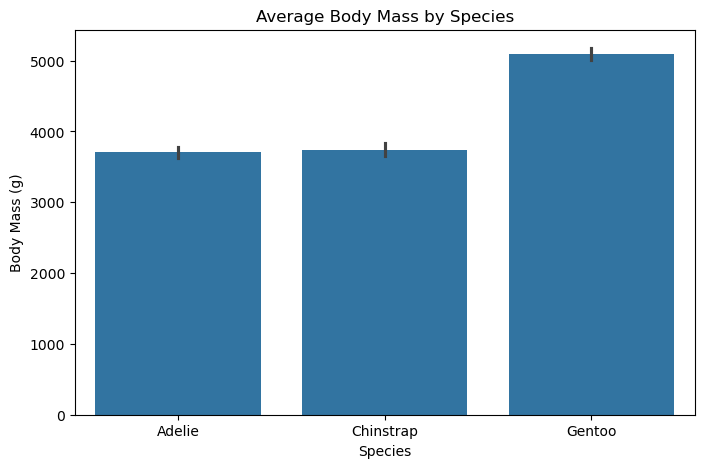

In [6]:
# Visualization 1: Categorical Comparison
## Average Body Mass by Species
plt.figure(figsize=(8,5))
sns.barplot(
    data=penguins_clean,
    x='species',
    y='body_mass_g'
)

plt.title('Average Body Mass by Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

### Interpretation
This chart compares average body mass among the three penguin species.

- Gentoo penguins tend to be the heaviest.
- Adelie penguins and Chinstrap penguins weigh similarly on average.


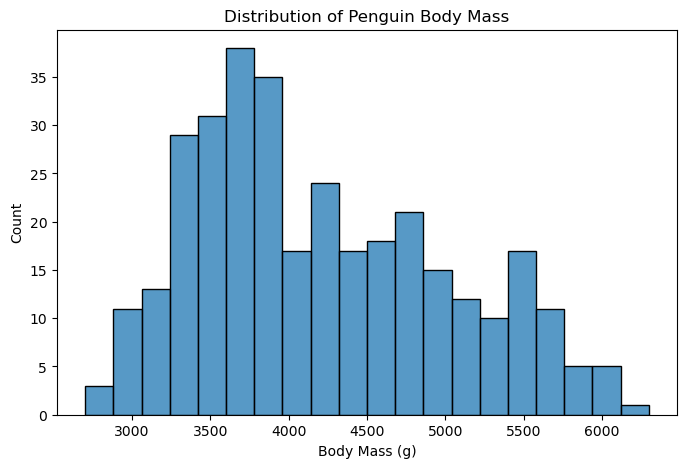

In [7]:
# Visualization 2: Distribution Chart
## Distribution of Body Mass
plt.figure(figsize=(8,5))
sns.histplot(
    penguins_clean['body_mass_g'],
    bins=20
)

plt.title('Distribution of Penguin Body Mass')
plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.show()

### Interpretation

This histogram shows how body mass is distributed across all penguins.

- Most penguins weigh between 3500 and 5000 grams.
- The distribution is not perfectly symmetrical because different species have different average sizes.
- Multiple peaks suggest distinct species groups within the dataset.

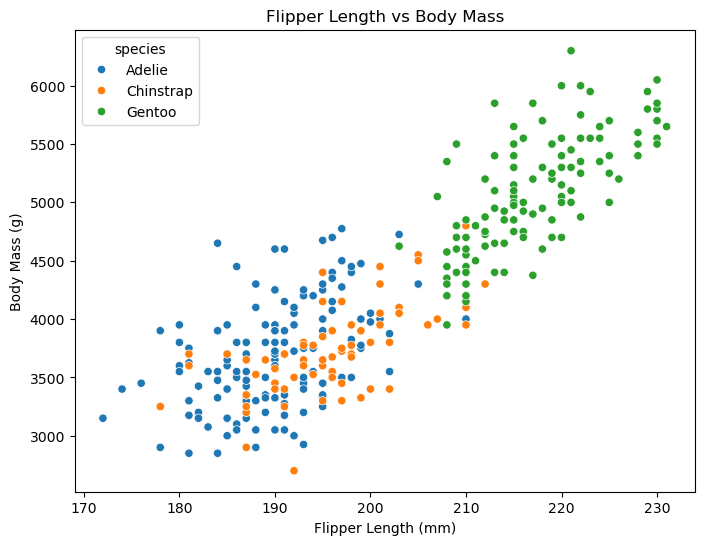

In [8]:
# Visualization 3: Relationship Chart
## Flipper Length vs Body Mass
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_clean,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species'
)

plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

### Interpretation

This scatter plot explores the relationship between flipper length and body mass.

- Penguins with longer flippers generally weigh more.
- Gentoo penguins cluster in the upper-right area because they have larger flippers and body mass.
- A positive relationship exists between flipper size and weight.

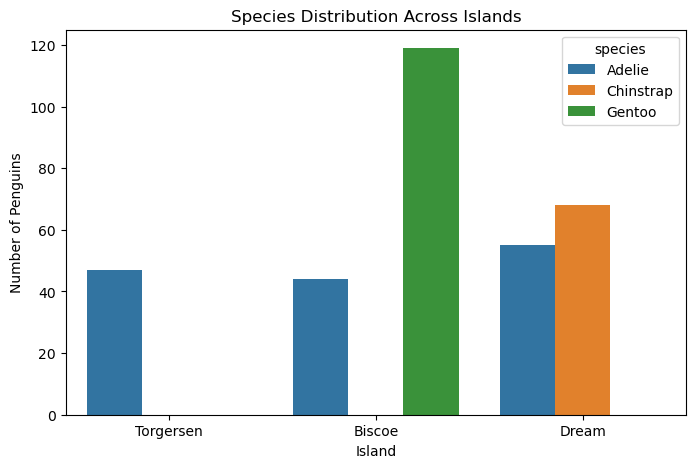

In [9]:
# Visualization 4: Student Choice
## Penguin Species by Island
plt.figure(figsize=(8,5))

sns.countplot(
    data=penguins_clean,
    x='island',
    hue='species'
)

plt.title('Species Distribution Across Islands')
plt.xlabel('Island')
plt.ylabel('Number of Penguins')
plt.show()

### Interpretation

This chart shows how penguin species are distributed across islands.

- Some species are concentrated on particular islands.
- Gentoo penguins are primarily found on Biscoe Island.
- Adelie penguins appear across multiple islands.
- Island location may influence species distribution and habitat preferences.